<a href="https://colab.research.google.com/github/Navathamarkeeri/air-quality-forecasting/blob/main/bmw_forecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df =pd.read_csv("/content/BMW sales data (2010-2024) (1).csv")

In [ ]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [ ]:
df.tail()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [ ]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [ ]:
df.isnull().sum()

,0
Model,0
Year,0
Region,0
Color,0
Fuel_Type,0
Transmission,0
Engine_Size_L,0
Mileage_KM,0
Price_USD,0
Sales_Volume,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Model,11
Year,15
Region,6
Color,6
Fuel_Type,4
Transmission,2
Engine_Size_L,36
Mileage_KM,44347
Price_USD,38246
Sales_Volume,9845


In [ ]:
df.shape

(50000, 11)

In [ ]:
df.dtypes

,0
Model,object
Year,int64
Region,object
Color,object
Fuel_Type,object
Transmission,object
Engine_Size_L,float64
Mileage_KM,int64
Price_USD,int64
Sales_Volume,int64


In [ ]:
df.columns

Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
       'Sales_Classification'],
      dtype='object')

In [ ]:
#2) Auto-detect date and sales columns (robust)
def detect_date_and_sales(df):
    date_col = None
    sales_col = None
    # prefer clear names
    for c in df.columns:
        if c.lower() in ['date','year','month','period']:
            date_col = c
            break
    # fallback: test parseability
    if date_col is None:
        for c in df.columns:
            try:
                parsed = pd.to_datetime(df[c].iloc[:30], errors='coerce')
                if parsed.notna().sum() >= 10:
                    date_col = c
                    break
            except Exception:
                pass
     # sales detection by keywords
    keywords = ['sales','sold','units','volume','revenue','amount','value','qty']
    for c in df.columns:
        for k in keywords:
            if k in c.lower():
                sales_col = c
                break
        if sales_col:
            break
    # fallback numeric highest variance
    if sales_col is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if numeric_cols:
            variances = {c: df[c].var() for c in numeric_cols}
            sales_col = max(variances, key=variances.get)
    return date_col, sales_col

date_col, sales_col = detect_date_and_sales(df)
print("Detected date column:", date_col)
print("Detected sales column:", sales_col)

Detected date column: Year
Detected sales column: Sales_Volume


In [ ]:
 #3) Prepare datetime column (handle Year-only integers specially)
if date_col is None:
    df['_date_'] = pd.date_range(start='2010-01-01', periods=len(df), freq='M')
    date_col = '_date_'
else:
    # if 'Year' contains values like 2010, 2011... convert to YYYY-01-01
    sample = df[date_col].dropna().astype(str).iloc[:50]
    is_year_like = sample.str.match(r'^\d{4}$').sum() >= max(3, int(0.6*len(sample)))
    if is_year_like:
        df[date_col] = df[date_col].astype(int).astype(str) + '-01-01'
    else:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=False)

df[sales_col] = pd.to_numeric(df[sales_col], errors='coerce')
df = df.dropna(subset=[date_col, sales_col]).copy()
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(by=date_col).reset_index(drop=True)

Aggregating by year (YS)
Time series length: 15 from 2010-01-01 00:00:00 to 2024-01-01 00:00:00


/tmp/ipython-input-670612746.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts['sales'] = ts['sales'].fillna(method='ffill').fillna(method='bfill')


,sales
Year,
2010-01-01,16933445
2011-01-01,16758941
2012-01-01,16751895
2013-01-01,16866733
2014-01-01,16958960
2015-01-01,17010207
2016-01-01,16957550
2017-01-01,16620811
2018-01-01,16412273


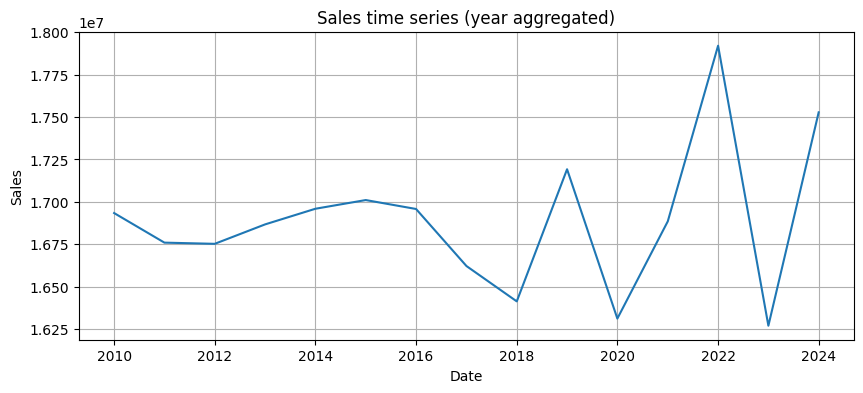

In [ ]:
# 4) Decide aggregation freq: monthly if month variety exists, otherwise yearly
has_month_info = df[date_col].dt.month.nunique() > 1 and df[date_col].nunique() > 12
agg_freq = 'MS' if has_month_info else 'YS'
agg_label = 'month' if has_month_info else 'year'
print(f"Aggregating by {agg_label} ({agg_freq})")

ts = df.groupby(pd.Grouper(key=date_col, freq=agg_freq))[sales_col].sum().rename('sales').to_frame()
ts = ts.asfreq(agg_freq)
ts['sales'] = ts['sales'].fillna(method='ffill').fillna(method='bfill')

print("Time series length:", len(ts), "from", ts.index.min(), "to", ts.index.max())
display(ts.head(12))

# plot series
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts['sales'])
plt.title(f"Sales time series ({agg_label} aggregated)")
plt.xlabel("Date"); plt.ylabel("Sales"); plt.grid(True)
plt.show()


In [ ]:
# 5) Prepare sequences
LOOK_BACK_DEFAULT = 12 # Define a default value for LOOK_BACK
LOOK_BACK = LOOK_BACK_DEFAULT if len(ts) >= (LOOK_BACK_DEFAULT + 1) else max(1, len(ts)-1)
print("Using look_back:", LOOK_BACK)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(ts[['sales']]).flatten()

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    X = np.array(X); y = np.array(y)
    if X.size == 0:
        return None, None
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

X, y = create_sequences(scaled, LOOK_BACK)
if X is None:
    raise ValueError("Not enough points to create sequences. Need at least look_back+1 points.")
  # chronological train-test split
TEST_MAX = 5 # Define a default value for TEST_MAX
test_size = min(TEST_MAX, max(1, int(0.2 * len(X))))
train_size = len(X) - test_size
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print("Train samples:", X_train.shape[0], "Test samples:", X_test.shape[0])

Using look_back: 12
Train samples: 2 Test samples: 1


In [ ]:
# 6) Build and train models (requires TensorFlow)
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except Exception as e:
    raise ImportError("TensorFlow is required to run training. If you're in Colab it's already present. Locally: pip install tensorflow\nError: " + str(e))

def build_rnn(look_back):
    model = Sequential([
        SimpleRNN(64, input_shape=(look_back,1)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    return model

def build_lstm(look_back):
    model = Sequential([
        LSTM(64, input_shape=(look_back,1)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    return model

def compile_and_train(model, X_tr, y_tr, X_val, y_val, epochs=200, batch_size=8):
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=1)
    return history

# small validation split from training
val_n = max(1, int(0.1 * len(X_train)))
X_val = X_train[-val_n:]
y_val = y_train[-val_n:]
X_tr = X_train[:-val_n]
y_tr = y_train[:-val_n]

print("Training on", X_tr.shape[0], "samples. Validating on", X_val.shape[0])

rnn_model = build_rnn(LOOK_BACK)
print("RNN summary:")
rnn_model.summary()
rnn_hist = compile_and_train(rnn_model, X_tr, y_tr, X_val, y_val, epochs=200, batch_size=4)

lstm_model = build_lstm(LOOK_BACK)
print("LSTM summary:")
lstm_model.summary()
lstm_hist = compile_and_train(lstm_model, X_tr, y_tr, X_val, y_val, epochs=200, batch_size=4)

Training on 1 samples. Validating on 1
RNN summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,953 (70.13 KB)

 Trainable params: 17,953 (70.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.9652 - mae: 0.9825 - val_loss: 0.0025 - val_mae: 0.0496
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.8900 - mae: 0.9434 - val_loss: 0.0046 - val_mae: 0.0682
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.9097 - mae: 0.9538 - val_loss: 0.0074 - val_mae: 0.0858
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8777 - mae: 0.9368 - val_loss: 0.0110 - val_mae: 0.1049
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.7997 - mae: 0.8943 - val_loss: 0.0158 - val_mae: 0.1258
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.8140 - mae: 0.9022 - val_loss: 0.0217 - val_mae: 0.1474
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8401 - mae: 0.9166 - val_loss: 0.0286 - val_mae: 0.1691
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.7477 - mae: 0.8647 - val_loss: 0.0364 - val_mae: 0.1907
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.7527 - 

In [ ]:
# 7) Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_and_inverse(model, X_t, y_t, scaler):
    y_pred_s = model.predict(X_t).flatten()
    y_pred = scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
    y_true = scaler.inverse_transform(y_t.reshape(-1,1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return y_true, y_pred, rmse, mae

r_true, r_pred, r_rmse, r_mae = evaluate_and_inverse(rnn_model, X_test, y_test, scaler)
l_true, l_pred, l_rmse, l_mae = evaluate_and_inverse(lstm_model, X_test, y_test, scaler)

print(f"RNN => RMSE: {r_rmse:.3f}, MAE: {r_mae:.3f}")
print(f"LSTM => RMSE: {l_rmse:.3f}, MAE: {l_mae:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
RNN => RMSE: 913353.000, MAE: 913353.000
LSTM => RMSE: 1191367.000, MAE: 1191367.000


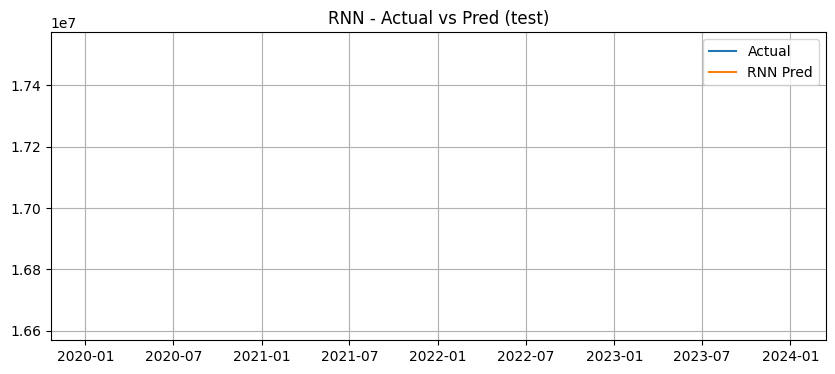

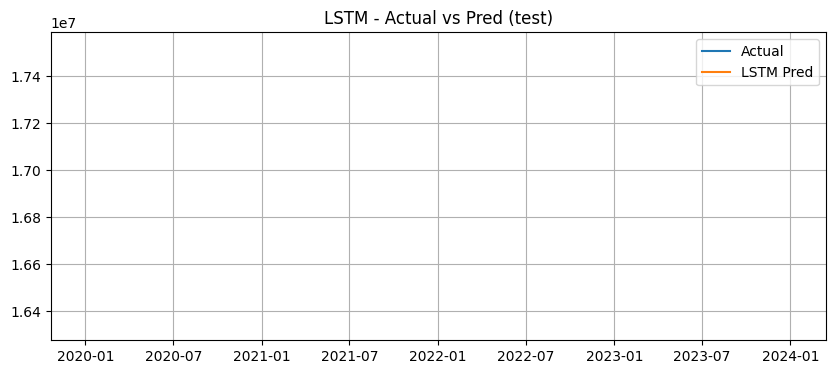

In [ ]:
# 8) Plot results (test)
test_index = ts.index[LOOK_BACK:LOOK_BACK + len(r_true)]

plt.figure(figsize=(10,4))
plt.plot(test_index, r_true, label='Actual')
plt.plot(test_index, r_pred, label='RNN Pred')
plt.title("RNN - Actual vs Pred (test)")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(10,4))
plt.plot(test_index, l_true, label='Actual')
plt.plot(test_index, l_pred, label='LSTM Pred')
plt.title("LSTM - Actual vs Pred (test)")
plt.legend(); plt.grid(True); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


,date,forecast_sales
0,2025-01-01,16163914.0
1,2026-01-01,16875084.0
2,2027-01-01,16381560.0
3,2028-01-01,16733993.0
4,2029-01-01,16137081.0
5,2030-01-01,16785844.0


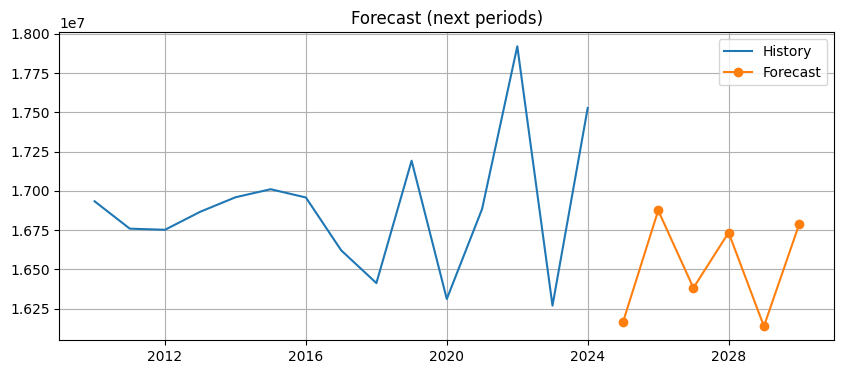

In [ ]:
# 9) Forecast next periods using the best model
best_model = lstm_model if l_rmse <= r_rmse else rnn_model
steps = 12 if agg_freq == 'MS' else 6
def forecast_future(model, scaled_series, look_back, steps, scaler):
    seq = scaled_series[-look_back:].tolist()
    preds = []
    for _ in range(steps):
        x = np.array(seq[-look_back:]).reshape(1, look_back, 1)
        yhat = model.predict(x).flatten()[0]
        preds.append(yhat)
        seq.append(yhat)
    return scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()

future_preds = forecast_future(best_model, scaled, LOOK_BACK, steps, scaler)
future_index = pd.date_range(start=ts.index.max() + (pd.offsets.MonthBegin(1) if agg_freq=='MS' else pd.offsets.YearBegin(1)), periods=steps, freq=agg_freq)

forecast_df = pd.DataFrame({'date': future_index, 'forecast_sales': future_preds})
display(forecast_df)

plt.figure(figsize=(10,4))
plt.plot(ts.index, ts['sales'], label='History')
plt.plot(future_index, future_preds, label='Forecast', marker='o')
plt.title("Forecast (next periods)")
plt.legend(); plt.grid(True); plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
label_encoders = {}
categorical_cols = ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [ ]:
X = df.drop("Sales_Classification", axis=1)
y = df["Sales_Classification"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [ ]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100  # in percentage
    results[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 99.86%
Decision Tree Accuracy: 100.00%
Random Forest Accuracy: 100.00%
Gradient Boosting Accuracy: 100.00%
SVM Accuracy: 99.58%
KNN Accuracy: 95.97%


In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Blues_d")
plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.ylim(0,100)
plt.show()